In [2]:
import requests
from datetime import datetime, timedelta
import pandas as pd
import time

# Replace with your actual API key
API_KEY = '4b4504a504e641868df232257250604'

# List of Canadian cities
cities = ['Toronto', 'Mississauga', 'Brampton', 'Markham', 'Vaughan', 'Richmond Hill', 'Oakville', 'Burlington',
          'Vancouver', 'Burnaby', 'Richmond', 'Surrey', 'Coquitlam', 'Delta', 'New Westminster', 'North Vancouver', 'West Vancouver',
          'Calgary', 'Airdrie', 'Cochrane', 'Okotoks', 'Chestermere', 'High River', 'Strathmore',
          'Montreal', 'Laval', 'Longueuil', 'Brossard', 'Terrebonne', 'Repentigny', 'Saint-Jean-sur-Richelieu',
          'Ottawa', 'Gatineau', 'Kanata', 'Nepean', 'Orleans', 'Gloucester']

# Number of past days
days = 7

# Function to fetch weather data
def fetch_weather_data(city, days):
    weather_data = []
    end_date = datetime.today()

    for i in range(days):
        date = end_date - timedelta(days=i)
        date_str = date.strftime('%Y-%m-%d')
        url = f"https://api.weatherapi.com/v1/history.json?key={API_KEY}&q={city}&dt={date_str}"

        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            day_data = data['forecast']['forecastday'][0]['day']
            weather_data.append({
                'city': city,
                'date': date_str,
                'avg_temp_c': day_data['avgtemp_c'],
                'max_temp_c': day_data['maxtemp_c'],
                'min_temp_c': day_data['mintemp_c'],
                'precipitation_mm': day_data['totalprecip_mm'],
                'humidity': day_data['avghumidity'],
                'condition': day_data['condition']['text'],
                'total_snow_cm': day_data['totalsnow_cm'],
                'daily_chance_of_rain': day_data['daily_chance_of_rain'],
                'wind_kph': day_data['maxwind_kph'],
                'uv': day_data['uv'],
                'sunrise': data['forecast']['forecastday'][0]['astro']['sunrise'],
                'sunset': data['forecast']['forecastday'][0]['astro']['sunset'],
                'cloud': data['forecast']['forecastday'][0]['hour'][0]['cloud']


            })
        else:
            print(f"Failed to fetch data for {city} on {date_str}. Status code: {response.status_code}")
        time.sleep(1)  # Respect rate limits

    return weather_data

# Main logic
def main():
    all_weather_data = []
    today_date = datetime.today().strftime('%Y-%m-%d')
    for city in cities:
        print(f"Fetching weather data for {city}")
        city_data = fetch_weather_data(city, days)
        all_weather_data.extend(city_data)

    # Convert to DataFrame and save
    weather_data = pd.DataFrame(all_weather_data)
    weather_data.to_csv(f"7_day_weather_canadian_cities_{today_date}.csv", index=False)
    print("✅ Data saved to 7_day_weather_canadian_cities.csv")

if __name__ == "__main__":
    main()


Fetching weather data for Toronto
Fetching weather data for Mississauga
Fetching weather data for Brampton
Fetching weather data for Markham
Fetching weather data for Vaughan
Fetching weather data for Richmond Hill
Fetching weather data for Oakville
Fetching weather data for Burlington
Fetching weather data for Vancouver
Fetching weather data for Burnaby
Fetching weather data for Richmond
Fetching weather data for Surrey
Fetching weather data for Coquitlam
Fetching weather data for Delta
Fetching weather data for New Westminster
Fetching weather data for North Vancouver
Fetching weather data for West Vancouver
Fetching weather data for Calgary
Fetching weather data for Airdrie
Fetching weather data for Cochrane
Fetching weather data for Okotoks
Fetching weather data for Chestermere
Fetching weather data for High River
Fetching weather data for Strathmore
Fetching weather data for Montreal
Fetching weather data for Laval
Fetching weather data for Longueuil
Fetching weather data for Bros

In [22]:

# Load the data
weather_data = pd.read_csv("7_day_weather_canadian_cities_2025-04-12.csv")

# Preview
print("Sample data:\n", weather_data.head())
print("\nColumn data types:")
print(weather_data.dtypes)

# Change 'date' to datetime
weather_data['date'] = pd.to_datetime(weather_data['date'])

# Fill missing values (if any)
weather_data.fillna({
    'total_snow_cm': 0,
    'precipitation_mm': 0,
    'daily_chance_of_rain': weather_data['daily_chance_of_rain'].mean(),
    'wind_kph': 0,
    'uv': weather_data['uv'].mean(),
    'cloud': weather_data['cloud'].mean()
}, inplace=True)

# Check duplicates
print("\nDuplicated rows in dataset:", weather_data.duplicated().sum())

# Normalize text fields
weather_data['condition'] = weather_data['condition'].str.lower()
weather_data['city'] = weather_data['city'].str.lower()

# === ✅ Compute daylight duration ===
def compute_daylight(df):
    # Convert to datetime
    df['sunrise_dt'] = df['sunrise'].apply(lambda x: datetime.strptime(x, "%I:%M %p"))
    df['sunset_dt'] = df['sunset'].apply(lambda x: datetime.strptime(x, "%I:%M %p"))
    # Calculate difference in hours
    df['daylight_duration'] = round((df['sunset_dt'] - df['sunrise_dt']).dt.total_seconds() / 3600, 2)
    return df

weather_data = compute_daylight(weather_data)

def city_to_province(weather_data):
    # Define province-to-cities mapping
  province_to_cities = {
      'Ontario': ['toronto', 'mississauga', 'brampton', 'markham', 'vaughan', 'richmond hill', 'oakville', 'burlington', 'ottawa', 'kanata', 'nepean', 'orleans', 'gloucester'],
      'British Columbia': ['vancouver', 'burnaby', 'richmond', 'surrey', 'coquitlam', 'delta', 'new westminster', 'north vancouver', 'west vancouver'],
      'Alberta': ['calgary', 'airdrie', 'cochrane', 'okotoks', 'chestermere', 'high river', 'strathmore'],
      'Quebec': ['montreal', 'laval', 'longueuil', 'brossard', 'terrebonne', 'repentigny', 'saint-jean-sur-richelieu', 'gatineau']
  }

  # Invert it to city-to-province
  city_to_province = {}
  for province, cities in province_to_cities.items():
      for city in cities:
          city_to_province[city] = province


  # Map province to the city in the DataFrame
  weather_data['province'] = weather_data['city'].map(city_to_province)
  return weather_data


# Apply the mapping function
weather_data = city_to_province(weather_data)

#####################################

#  1. Rainy Day: If chance of rain > 50%
weather_data['is_rainy'] = weather_data['daily_chance_of_rain'] > 50

# 2. Feels Cold: If min temperature is below freezing
weather_data['is_cold'] = weather_data['min_temp_c'] < 0

#  3. Cloudy Day: If cloud cover is more than 70%
weather_data['is_cloudy'] = weather_data['cloud'] > 70

#  4. Long Day: If daylight duration > 12 hours (in seconds)
weather_data['is_long_day'] = weather_data['daylight_duration'] > (12 * 3600)

# Optional: Convert boolean flags to integers (0/1) if you're using them in ML models
weather_data[['is_rainy', 'is_cold', 'is_cloudy', 'is_long_day']] = \
    weather_data[['is_rainy', 'is_cold', 'is_cloudy', 'is_long_day']].astype(int)

###########################

### Max Temperature Over Last 7 Days
weather_data['max_temp_last_7_days'] = weather_data['max_temp_c'].rolling(window=7, min_periods=1).max()
### Average Wind Speed Over Last 7 Days
weather_data['avg_wind_speed_last_7_days'] = weather_data['wind_kph'].rolling(window=7, min_periods=1).mean()



# Preview final
print("\nCleaned data preview:\n", weather_data.head())


Sample data:
       city        date  avg_temp_c  max_temp_c  min_temp_c  precipitation_mm  \
0  Toronto  2025-04-12         4.7         7.1         2.8              0.00   
1  Toronto  2025-04-11         3.4         4.2         2.5              4.67   
2  Toronto  2025-04-10         1.6         3.1        -0.0             12.79   
3  Toronto  2025-04-09         0.0         5.4        -4.1              0.00   
4  Toronto  2025-04-08        -2.2         1.0        -4.8              0.00   

   humidity                      condition  total_snow_cm  \
0        91                           Mist            0.0   
1        95                       Overcast            0.0   
2        82  Moderate or heavy rain shower            0.0   
3        62                       Overcast            0.0   
4        63                       Overcast            0.0   

   daily_chance_of_rain  wind_kph   uv   sunrise    sunset  cloud  
0                     0      13.7  2.0  06:39 AM  07:58 PM     96  
1 

Feature Engineering

In [5]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

### Max Temperature Over Last 7 Days
weather_data['max_temp_last_7_days'] = weather_data['max_temp_c'].rolling(window=7, min_periods=1).max()
### Average Wind Speed Over Last 7 Days
weather_data['avg_wind_speed_last_7_days'] = weather_data['wind_kph'].rolling(window=7, min_periods=1).mean()


## Normalized Variables: Normalize continuous variables like temperature, humidity, and wind speed so that all features contribute equally to the model.
# Normalize continuous features
weather_data[['avg_temp_c', 'max_temp_c', 'min_temp_c', 'precipitation_mm', 'humidity', 'wind_kph', 'uv', 'cloud', 'total_snow_cm']] = scaler.fit_transform(
    weather_data[['avg_temp_c', 'max_temp_c', 'min_temp_c', 'precipitation_mm', 'humidity', 'wind_kph', 'uv', 'cloud', 'total_snow_cm']]
)

weather_data.head()


,city,date,avg_temp_c,max_temp_c,min_temp_c,precipitation_mm,humidity,condition,total_snow_cm,daily_chance_of_rain,...,uv,sunrise,sunset,cloud,sunrise_dt,sunset_dt,daylight_duration,province,max_temp_last_7_days,avg_wind_speed_last_7_days
0,toronto,2025-04-12,-0.023229,-0.325561,0.356057,-0.319845,1.266397,mist,-0.241998,0,...,-0.453079,06:39 AM,07:58 PM,0.999351,1900-01-01 06:39:00,1900-01-01 19:58:00,13.32,Ontario,7.1,13.700000
1,toronto,2025-04-11,-0.334831,-0.928741,0.287374,-0.027016,1.575172,overcast,-0.241998,100,...,-1.335390,06:41 AM,07:57 PM,1.092995,1900-01-01 06:41:00,1900-01-01 19:57:00,13.27,Ontario,7.1,14.750000
2,toronto,2025-04-10,-0.766280,-1.157533,-0.284987,0.482143,0.571652,moderate or heavy rain shower,-0.241998,100,...,-1.335390,06:43 AM,07:56 PM,-1.084227,1900-01-01 06:43:00,1900-01-01 19:56:00,13.22,Ontario,7.1,18.466667
3,toronto,2025-04-09,-1.149791,-0.679149,-1.223659,-0.319845,-0.972226,overcast,-0.241998,0,...,-0.453079,06:44 AM,07:55 PM,-1.248104,1900-01-01 06:44:00,1900-01-01 19:55:00,13.18,Ontario,7.1,17.625000
4,toronto,2025-04-08,-1.677117,-1.594318,-1.383921,-0.319845,-0.895032,overcast,-0.241998,0,...,-1.335390,06:46 AM,07:53 PM,0.320432,1900-01-01 06:46:00,1900-01-01 19:53:00,13.12,Ontario,7.1,19.940000


### 1. . Temperature & Climate Analysis

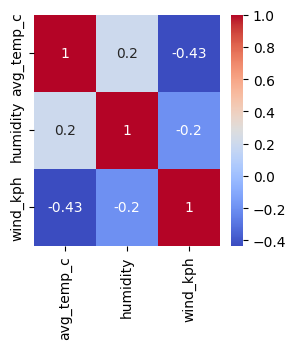

<ipython-input-7-1d3515ba3e80>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_temp_c', y='city', data=city_avg_temp, palette='coolwarm')


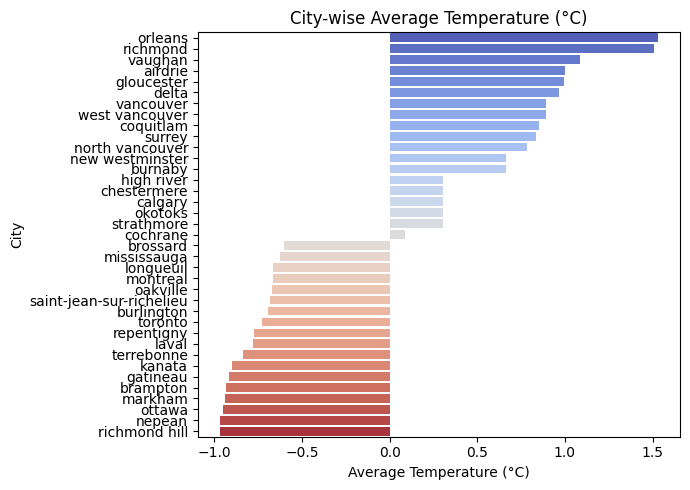

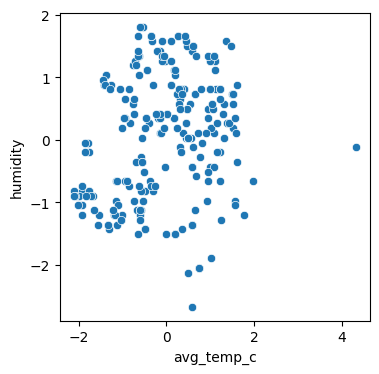

In [7]:
# Correlation between temperature, humidity, wind
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = weather_data[['avg_temp_c', 'humidity', 'wind_kph']].corr()
plt.figure(figsize=(3, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()
# City-wise average temperature
city_avg_temp = weather_data.groupby('city')['avg_temp_c'].mean().sort_values(ascending=False).reset_index()
# Plot using barplot to show city names
plt.figure(figsize=(7, 5))
sns.barplot(x='avg_temp_c', y='city', data=city_avg_temp, palette='coolwarm')

plt.title('City-wise Average Temperature (°C)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

# Scatter plot of temp vs humidity
plt.figure(figsize=(4, 4))
sns.scatterplot(x='avg_temp_c', y='humidity', data=weather_data)
plt.show()

### 2.  2. Rain & Snow Insights

              city  precipitation_mm
0         richmond         18.863600
1  north vancouver          6.187918
2        coquitlam          4.121810
3  new westminster          3.676609
4          burnaby          3.676609


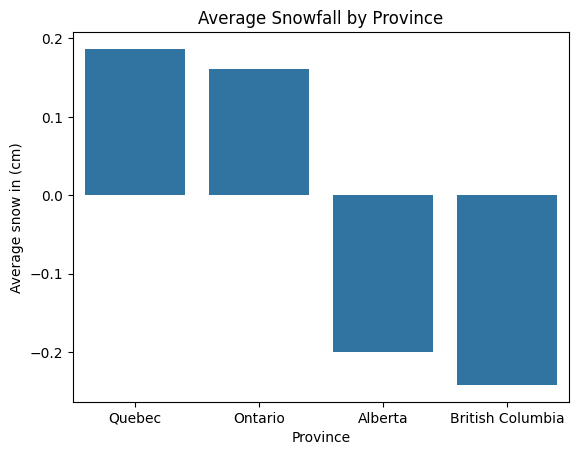

In [8]:
### a) Total precipitation per city

# Sum of all rainfall for each city
total_precip_by_city = weather_data.groupby('city')['precipitation_mm'].sum().sort_values(ascending=False).reset_index()
print(total_precip_by_city.head())

### b) Average snowfall by province
# Average snowfall for each province
avg_snow_by_province = weather_data.groupby('province')['total_snow_cm'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='province', y='total_snow_cm', data=avg_snow_by_province)
plt.title('Average Snowfall by Province')
plt.xlabel('Province')
plt.ylabel('Average snow in (cm)')
plt.show()


### 3. Sunlight & Daylight Analysis

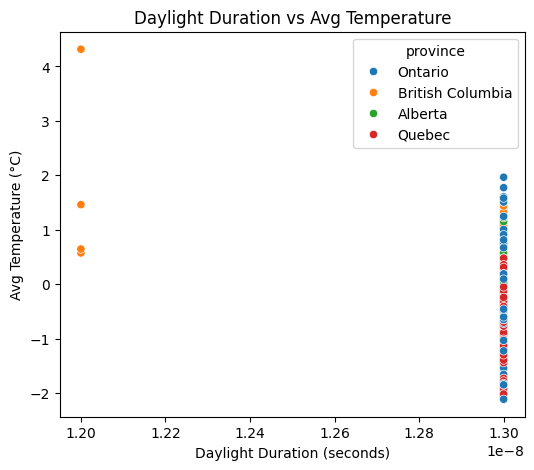

In [9]:
### a) Convert daylight duration to seconds.

# Convert "HH:MM:SS" to total seconds

weather_data['daylight_sec'] = pd.to_timedelta(weather_data['daylight_duration']).dt.total_seconds()

# b) Daylight vs Avg Temp plot

plt.figure(figsize=(6, 5))
sns.scatterplot(x='daylight_sec', y='avg_temp_c', hue='province', data=weather_data)
plt.title("Daylight Duration vs Avg Temperature")
plt.xlabel("Daylight Duration (seconds)")
plt.ylabel("Avg Temperature (°C)")
plt.show()

### 4. Weather Condition Frequency

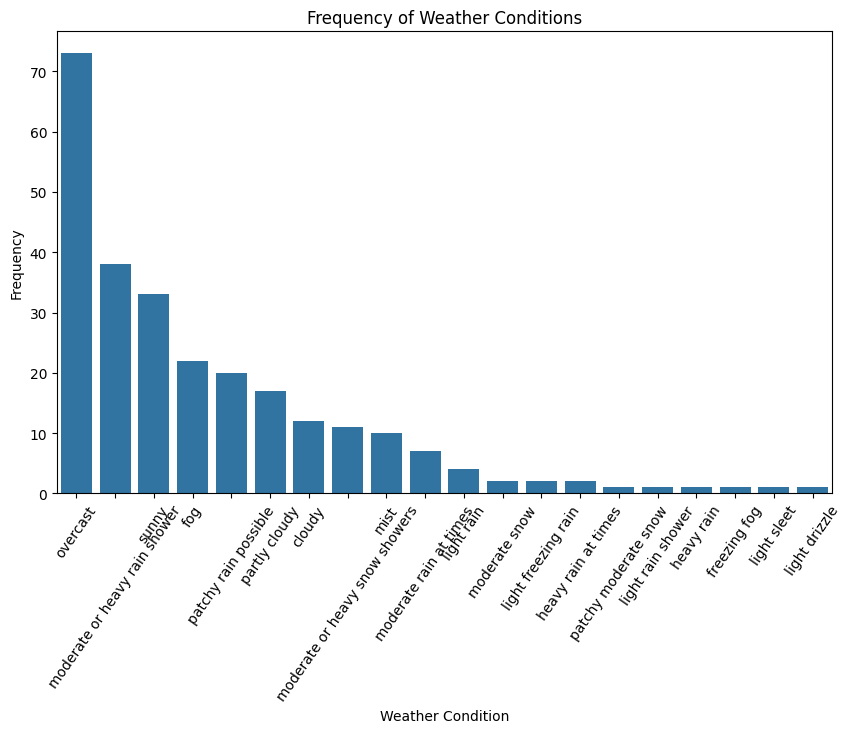

In [10]:
## a) Top conditions overall

# Count of each unique weather condition
plt.figure(figsize=(10, 6))
condition_counts = weather_data['condition'].value_counts()
sns.barplot(x=condition_counts.index, y=condition_counts.values)
plt.title("Frequency of Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Frequency")
plt.xticks(rotation=55)
plt.show()


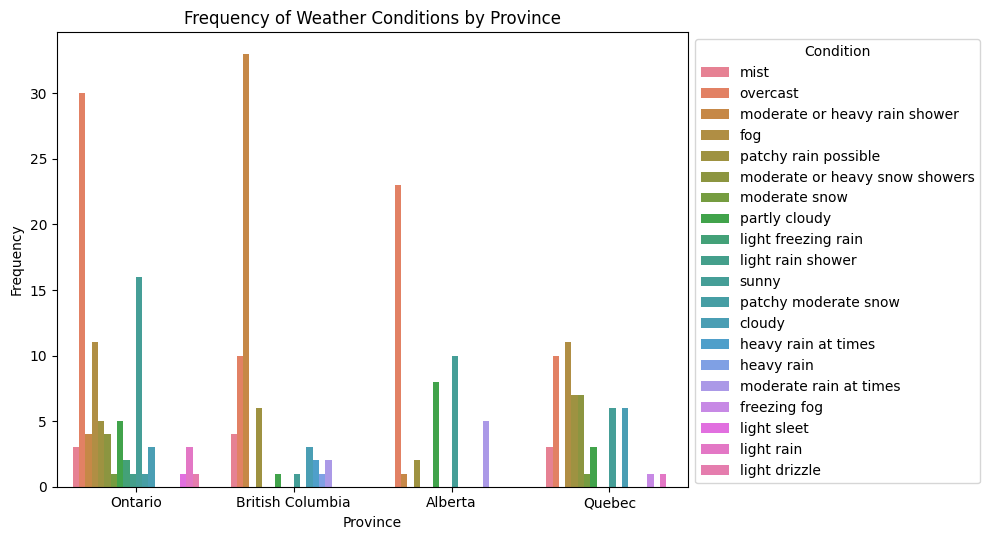

In [18]:
## b) Condition distribution by province

# Frequency of each weather condition by province
plt.figure(figsize=(10, 5.5))

sns.countplot(data = weather_data, x = 'province', hue= 'condition')
plt.title("Frequency of Weather Conditions by Province")
plt.xlabel("Province")
plt.ylabel("Frequency")
plt.legend(title='Condition', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [21]:
weather_data.columns

Index(['city', 'date', 'avg_temp_c', 'max_temp_c', 'min_temp_c',
       'precipitation_mm', 'humidity', 'condition', 'total_snow_cm',
       'daily_chance_of_rain', 'wind_kph', 'uv', 'sunrise', 'sunset', 'cloud',
       'sunrise_dt', 'sunset_dt', 'daylight_duration', 'province',
       'max_temp_last_7_days', 'avg_wind_speed_last_7_days', 'daylight_sec',
       'is_rainy', 'is_cold', 'is_cloudy', 'is_long_day'],
      dtype='object')

### 5. Create Custom Categories (Feature Engineering)

In [20]:
# 🌧️ 1. Rainy Day: If chance of rain > 50%
weather_data['is_rainy'] = weather_data['daily_chance_of_rain'] > 50

# 🌡️ 2. Feels Cold: If min temperature is below freezing
weather_data['is_cold'] = weather_data['min_temp_c'] < 0

# 🌥️ 3. Cloudy Day: If cloud cover is more than 70%
weather_data['is_cloudy'] = weather_data['cloud'] > 70

# ☀️ 4. Long Day: If daylight duration > 12 hours (in seconds)
weather_data['is_long_day'] = weather_data['daylight_duration'] > (12 * 3600)

# Optional: Convert boolean flags to integers (0/1) if you're using them in ML models
weather_data[['is_rainy', 'is_cold', 'is_cloudy', 'is_long_day']] = \
    weather_data[['is_rainy', 'is_cold', 'is_cloudy', 'is_long_day']].astype(int)

# Preview the result
weather_data[['date', 'city', 'min_temp_c', 'daily_chance_of_rain', 'cloud', 'daylight_duration',
              'is_rainy', 'is_cold', 'is_cloudy', 'is_long_day']].head()


,date,city,min_temp_c,daily_chance_of_rain,cloud,daylight_duration,is_rainy,is_cold,is_cloudy,is_long_day
0,2025-04-12,toronto,0.356057,0,0.999351,13.32,0,0,0,0
1,2025-04-11,toronto,0.287374,100,1.092995,13.27,1,0,0,0
2,2025-04-10,toronto,-0.284987,100,-1.084227,13.22,1,1,0,0
3,2025-04-09,toronto,-1.223659,0,-1.248104,13.18,0,1,0,0
4,2025-04-08,toronto,-1.383921,0,0.320432,13.12,0,1,0,0


Encode the target variable weather conditions.

In [4]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le = LabelEncoder()

# Create a new column for encoded target
weather_data['condition_encoded'] = le.fit_transform(weather_data['condition'])

# Optional: Print mapping for interpretation
condition_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Condition to Label Mapping:", condition_mapping)
print("Updated column names: ", weather_data.columns)


Condition to Label Mapping: {'cloudy': np.int64(0), 'fog': np.int64(1), 'heavy rain at times': np.int64(2), 'heavy snow': np.int64(3), 'light freezing rain': np.int64(4), 'light sleet': np.int64(5), 'mist': np.int64(6), 'moderate or heavy rain shower': np.int64(7), 'moderate or heavy snow showers': np.int64(8), 'moderate rain': np.int64(9), 'moderate rain at times': np.int64(10), 'moderate snow': np.int64(11), 'overcast': np.int64(12), 'partly cloudy': np.int64(13), 'patchy rain possible': np.int64(14), 'sunny': np.int64(15), 'thundery outbreaks possible': np.int64(16)}
Updated column names:  Index(['city', 'date', 'avg_temp_c', 'max_temp_c', 'min_temp_c',
       'precipitation_mm', 'humidity', 'condition', 'total_snow_cm',
       'daily_chance_of_rain', 'wind_kph', 'uv', 'sunrise', 'sunset', 'cloud',
       'sunrise_dt', 'sunset_dt', 'daylight_duration', 'province',
       'max_temp_last_7_days', 'avg_wind_speed_last_7_days',
       'condition_encoded'],
      dtype='object')


Model Preparation

In [5]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'avg_temp_c', 'max_temp_c', 'min_temp_c',
    'precipitation_mm', 'humidity', 'wind_kph', 'uv', 'cloud', 'total_snow_cm',
    'max_temp_last_7_days', 'avg_wind_speed_last_7_days']

# Count each condition class
class_counts = weather_data['condition_encoded'].value_counts()

# Keep only those classes with at least 2 records
valid_classes = class_counts[class_counts >= 2].index

# Filter the dataset
weather_data_filtered = weather_data[weather_data['condition_encoded'].isin(valid_classes)]

# Now redefine X and y
X = weather_data_filtered[feature_cols]
y = weather_data_filtered['condition_encoded']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
# Import KNN and evaluation tools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the KNN classifier with a chosen number of neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.5384615384615384
Confusion Matrix:
 [[1 1 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 6 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 9 0 0 3]
 [0 0 0 0 0 0 0 0 0 0 0 0 4 0 1]
 [1 0 0 0 0 0 2 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 2 2 0 4]]
Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.25      0.22         4
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       0.00      0.00      0.00         0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_